In [ ]:
import pandas as pd

student_info = pd.read_csv("../Data/Raw/studentInfo.csv")
student_vle = pd.read_csv("../Data/Raw/studentVle.csv")

In [ ]:
stem_modules = ["CCC", "DDD", "EEE", "FFF", "GGG"]

stem_student_info = student_info[
    student_info["code_module"].isin(stem_modules)
].copy()

In [ ]:
stem_clicks = (
    student_vle
    .groupby("id_student")["sum_click"]
    .sum()
    .reset_index(name="total_clicks")
)

stem_df = stem_student_info.merge(
    stem_clicks,
    on="id_student",
    how="left"
)

stem_df["total_clicks"] = stem_df["total_clicks"].fillna(0)

In [ ]:
stem_df["success"] = stem_df["final_result"].isin(
    ["Pass", "Distinction"]
).astype(int)

In [ ]:
features = [
    "gender",
    "highest_education",
    "imd_band",
    "age_band",
    "num_of_prev_attempts",
    "studied_credits",
    "disability",
    "total_clicks"
]

In [ ]:
X = stem_df[features]
y = stem_df["success"]

In [ ]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

In [ ]:
X_encoded.columns = (
    X_encoded.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "lt", regex=False)
    .str.replace(">", "gt", regex=False)
    .str.replace("%", "pct", regex=False)
    .str.replace("-", "_", regex=False)
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = xgb.predict_proba(X_test)[:, 1]

stem_roc = roc_auc_score(
    y_test,
    y_prob
)

print("STEM ROC-AUC:", stem_roc)

STEM ROC-AUC: 0.8770812230043598


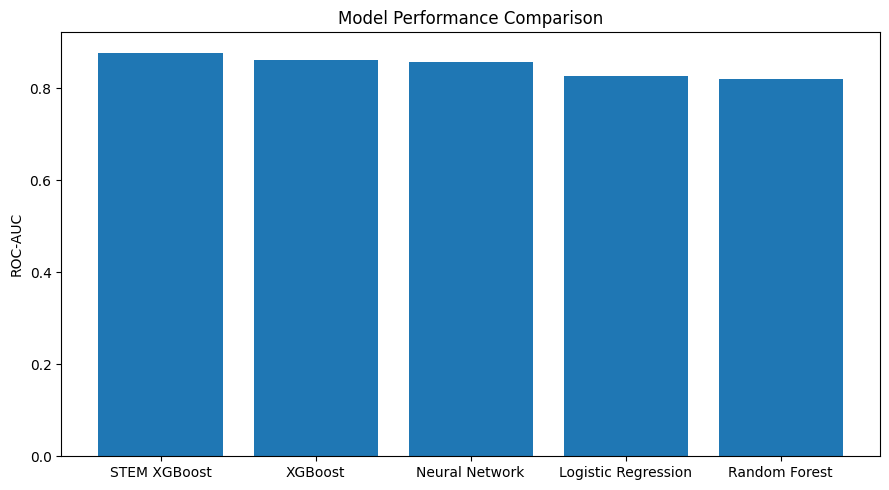

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "Neural Network",
        "XGBoost",
        "STEM XGBoost"
    ],
    "ROC_AUC": [
        0.8202,
        0.8264,
        0.8571,
        0.8614,
        0.8771
    ]
})

comparison = comparison.sort_values(
    "ROC_AUC",
    ascending=False
)

plt.figure(figsize=(9,5))

plt.bar(
    comparison["Model"],
    comparison["ROC_AUC"]
)

plt.title("Model Performance Comparison")
plt.ylabel("ROC-AUC")

plt.tight_layout()

plt.savefig(
    "../Figures/final_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

XGBoost achieved the strongest predictive performance overall (ROC-AUC = 0.861), while a STEM-specific XGBoost model achieved even higher performance (ROC-AUC = 0.877). Student engagement within the virtual learning environment emerged as the dominant predictor of success, suggesting that behavioral indicators provide powerful opportunities for early intervention and retention efforts in STEM education.

## STEM-Specific XGBoost Model Results

To further investigate whether predictive performance could be improved within a more homogeneous academic population, a STEM-specific analysis was conducted using students enrolled in STEM-related modules (CCC, DDD, EEE, FFF, and GGG). These courses included 23,936 students and exhibited higher rates of failure and withdrawal than the overall population, making them an important target for predictive intervention efforts.

The STEM-specific XGBoost model achieved the strongest performance of all models evaluated in this study, with a ROC-AUC score of **0.8771**. This result exceeded the performance of the full-population XGBoost model (ROC-AUC = 0.8614) and all other machine learning and deep learning approaches examined.

Consistent with earlier findings, student engagement emerged as the most influential predictor of academic success. Students who earned distinctions averaged over 3,500 VLE clicks, while students who failed or withdrew averaged fewer than 1,000 clicks. Educational preparation and socioeconomic status also demonstrated meaningful relationships with student outcomes.

The improved performance of the STEM-specific model suggests that student success patterns may be more predictable within discipline-focused populations. These findings support the potential value of developing targeted predictive analytics systems tailored to specific academic fields rather than relying solely on institution-wide models.

Overall, the STEM XGBoost model demonstrates that machine learning can accurately identify students at risk of academic difficulty and may serve as the foundation for future early-alert systems, targeted advising initiatives, and retention-focused interventions within STEM education.